In [12]:
import sys
!{sys.executable} -m pip install xgboost

In [13]:
import sys
print(sys.executable)


c:\Users\david\AppData\Local\Programs\Python\Python313\python.exe


In [14]:
import xgboost as xgb
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
import torch
import torch.nn as nn
from torch.utils.data import dataloader, TensorDataset

In [15]:
import pickle

with open("../data/train_test_data.pk1", "rb") as f:
    data = pickle.load(f)

x_trained_scaled = data['x_trained_scaled']
x_test_scaled = data['x_test_scaled']
y_train = data['y_train']
y_test = data['y_test']
features = data['features']

print(f'Data loaded.')
print(f'X_train shape: {x_trained_scaled.shape}')
print(f'X_test shape: {x_test_scaled.shape}')

Data loaded.
X_train shape: (967, 9)
X_test shape: (242, 9)


In [16]:
#let us create a model evaluation function w/ MAE and RMSE

def evaluate_model(name,y_true, y_pred):
    """
    Evalautes a regression model with metrics such as MAE, RMSE and directional accuracy
    Return a dict so it can be logged as a comparison table amongst different models
    """
    y_true = np.array(y_true).flatten()
    y_pred = np.array(y_pred).flatten()
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)

    actual_direction = np.sign(np.diff(y_true))
    pred_direction = np.sign(np.diff(y_pred))
    dir_accuracy = np.mean(actual_direction == pred_direction) * 100

    print(f"\n{'='*40}")
    print(f"Model:                {name}")
    print(f"  RMSE:                 {rmse}")
    print(f"  MAE:                  {mae}")
    print(f"  Directional Accuracy: {dir_accuracy:.2f}%")
    print(f"\n{'='*40}")

    return{
        "model" : name,
        "rmse" : rmse,
        "mae": mae,
        "directional_accuracy": round(dir_accuracy,2)
    }

In [17]:
xgb_model = XGBRegressor(
    n_estimators =1000,
    learning_rate =0.05,
    max_depth = 5,
    subsample = 0.8,
    colsample_bytree=0.8,
    random_state = 42
)
#let's fit the model
xgb_model.fit(
    x_trained_scaled, y_train,
    eval_set =[(x_test_scaled, y_test)],
    verbose = False
)
y_pred_xgb = xgb_model.predict(x_test_scaled)
result={}
result['XGBoost']= evaluate_model("XGBoost", y_test, y_pred_xgb)


Model:                XGBoost
  RMSE:                 10.805715522050752
  MAE:                  8.392226290111699
  Directional Accuracy: 66.80%



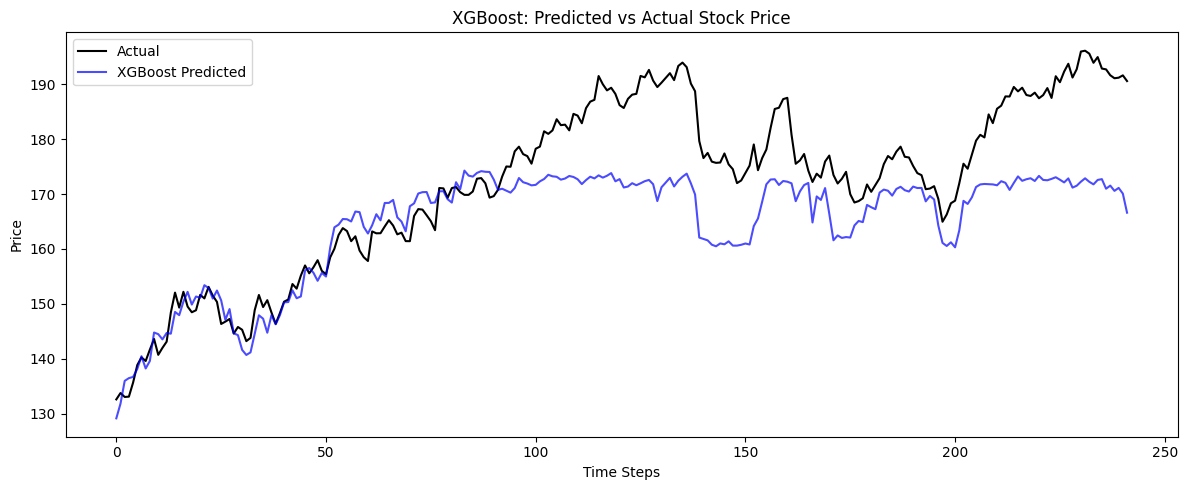

In [18]:
plt.figure(figsize=(12, 5))
plt.plot(np.array(y_test).flatten(), label='Actual', color='black')
plt.plot(y_pred_xgb, label='XGBoost Predicted', color='blue', alpha=0.7)
plt.title('XGBoost: Predicted vs Actual Stock Price')
plt.xlabel('Time Steps')
plt.ylabel('Price')
plt.legend()
plt.tight_layout()
plt.show()

In [19]:
from sklearn.linear_model import LinearRegression

lr_model = LinearRegression()
lr_model.fit(x_trained_scaled, y_train)
y_pred_lr = lr_model.predict(x_test_scaled)
result['LinearRegression'] = evaluate_model("Linear Regression", y_test, y_pred_lr)


Model:                Linear Regression
  RMSE:                 2.067375758516352
  MAE:                  1.578431575355275
  Directional Accuracy: 68.88%



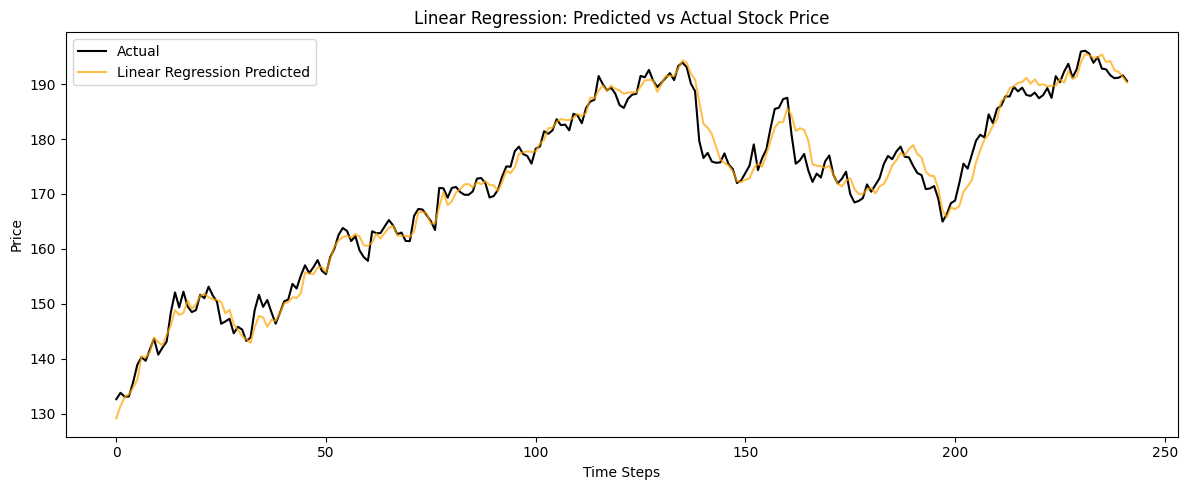

In [20]:
plt.figure(figsize=(12, 5))
plt.plot(np.array(y_test).flatten(), label='Actual', color='black')
plt.plot(y_pred_lr, label='Linear Regression Predicted', color='orange', alpha=0.7)
plt.title('Linear Regression: Predicted vs Actual Stock Price')
plt.xlabel('Time Steps')
plt.ylabel('Price')
plt.legend()
plt.tight_layout()
plt.show()

In [21]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators =100,
    max_depth = 6,
    max_features =0.8,
    random_state =42)

rf_model.fit(x_trained_scaled, y_train)
y_pred_rf = rf_model.predict(x_test_scaled)
result['RandomForest'] = evaluate_model('RandomForest', y_test, y_pred_rf)



Model:                RandomForest
  RMSE:                 10.598337386791455
  MAE:                  8.051119313324143
  Directional Accuracy: 63.90%



c:\Users\david\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\base.py:1336: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


In [30]:
#add another dim to the data. this will tell the model to look back a certain amount of days
def create_sequences(X,y, lookback=30):
    Xs , ys = [],[]
    for i in range(lookback, len(X)):
        Xs.append(X[i - lookback: i]) # this adds 30 days of features
        ys.append(y[i]) # the day of
    
    return np.array(Xs), np.array(ys)

In [32]:
x_seq, y_seq = create_sequences(x_trained_scaled, np.array(y_train), lookback= 30)
print(x_seq.shape)

(937, 30, 9)
